In [3]:
import os
import numpy as np
import pandas as pd
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import itertools
import random
import matplotlib.pyplot as plt
import seaborn as sns

import random
random.seed(42)
np.random.seed(42)

In [4]:
BASE_DIR = "/projects/standard/kumarv/shared/daycent/new_data"
INPUT_DIR = os.path.join(BASE_DIR, "inputs")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
POINTS_LOOKUP = os.path.join(BASE_DIR, "inputs/Midwest_lookupTable.xlsx")

PROCESSED_DIR = "/projects/standard/kumarv/shared/daycent/new_data/eda"

WEATHER_DIR = os.path.join(INPUT_DIR, "Weather")
INITC_FN = os.path.join(INPUT_DIR, "initial_site_conditions.xlsx")

HARVEST_FN = os.path.join(OUTPUT_DIR, "batch_001_010/scenario_1/SAS_scenario_1_harvest.csv")

SCENARIOS_FN = os.path.join(INPUT_DIR, "schedule_management_history_scen1_200.csv")

In [3]:
len(os.listdir(WEATHER_DIR))

9755

In [4]:
all_points = []

for points in os.listdir(WEATHER_DIR)[:20]:
    df = pd.read_csv(os.path.join(WEATHER_DIR, points))
    df['point_id'] = points.split(".csv")[0]
    all_points.append(df)

weather_df = pd.concat(all_points, ignore_index=True)
weather_df

,Year,DOY,Tmax,Tmin,Precip,point_id
0,2000,1,10.610,-8.280,0.000,100893
1,2000,2,1.550,-5.260,0.077,100893
2,2000,3,-0.090,-4.090,0.123,100893
3,2000,4,-2.670,-16.130,0.000,100893
4,2000,5,-5.410,-17.630,0.000,100893
...,...,...,...,...,...,...
182635,2024,362,-5.410,-10.980,0.000,11841
182636,2024,363,-1.125,-10.973,0.000,11841
182637,2024,364,1.823,-4.771,0.000,11841
182638,2024,365,-0.565,-9.022,0.000,11841


# EDA

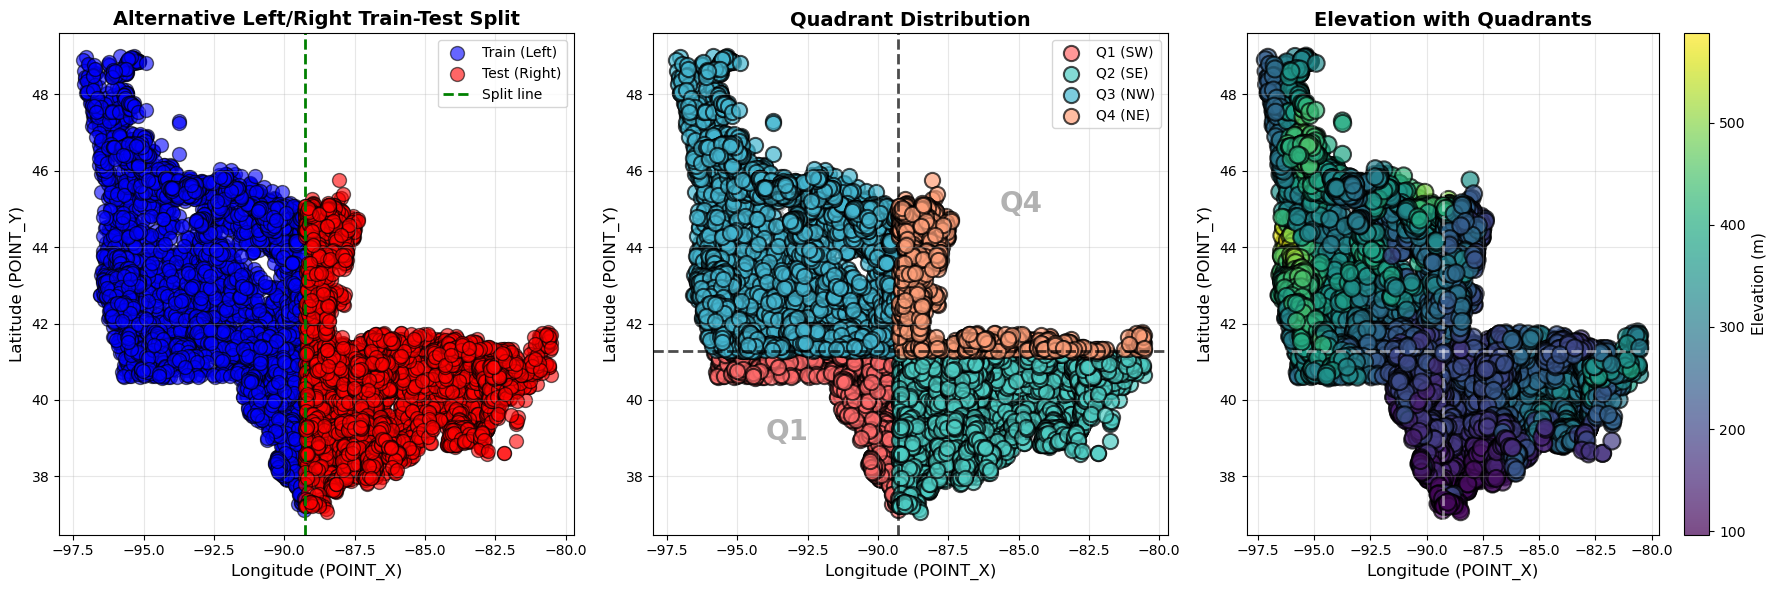

SPATIAL SPLIT SUMMARY

Total points: 9755
Split boundary X (Longitude): -89.272745
Split boundary Y (Latitude): 41.272143

--- LEFT/RIGHT SPLIT ---
Training points (Left): 4878 (50.0%)
Testing points (Right): 4877 (50.0%)

--- QUADRANT DISTRIBUTION ---
Q1 (SW): 1101 points (11.3%)
Q2 (SE): 3777 points (38.7%)
Q3 (NW): 3777 points (38.7%)
Q4 (NE): 1100 points (11.3%)

--- ELEVATION STATISTICS BY QUADRANT ---
Q1 (SW): Mean=217.11m, Min=96.93m, Max=404.68m
Q2 (SE): Mean=227.49m, Min=97.13m, Max=432.02m
Q3 (NW): Mean=341.98m, Min=162.69m, Max=587.32m
Q4 (NE): Mean=256.93m, Min=160.23m, Max=496.34m

ALTERNATIVE: CHECKERBOARD TRAIN-TEST SPLIT
Train (Q1): 1101 points
Test (Q4): 1100 points


In [13]:
df = pd.read_excel(POINTS_LOOKUP)

# Calculate medians for splitting
median_x = df['POINT_X'].median()
median_y = df['POINT_Y'].median()

# Create quadrants
df['quadrant'] = 'Q1'
df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q1 (SW)'
df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] <= median_y), 'quadrant'] = 'Q2 (SE)'
df.loc[(df['POINT_X'] <= median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q3 (NW)'
df.loc[(df['POINT_X'] > median_x) & (df['POINT_Y'] > median_y), 'quadrant'] = 'Q4 (NE)'

# Method 1: Left/Right split for train-test
left_half = df[df['POINT_X'] <= median_x]
right_half = df[df['POINT_X'] > median_x]

# Visualization
fig = plt.figure(figsize=(18, 6))

# Plot 1: Left/Right Train-Test Split
ax1 = plt.subplot(131)
ax1.scatter(left_half['POINT_X'], left_half['POINT_Y'], 
           c='blue', s=100, alpha=0.6, label='Train (Left)', edgecolors='black')
ax1.scatter(right_half['POINT_X'], right_half['POINT_Y'], 
           c='red', s=100, alpha=0.6, label='Test (Right)', edgecolors='black')
ax1.axvline(median_x, color='green', linestyle='--', linewidth=2, label='Split line')
ax1.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax1.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax1.set_title('Alternative Left/Right Train-Test Split', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Quadrant Visualization
ax2 = plt.subplot(132)
colors = {'Q1 (SW)': '#FF6B6B', 'Q2 (SE)': '#4ECDC4', 'Q3 (NW)': '#45B7D1', 'Q4 (NE)': '#FFA07A'}
for quadrant, color in colors.items():
    mask = df['quadrant'] == quadrant
    ax2.scatter(df.loc[mask, 'POINT_X'], df.loc[mask, 'POINT_Y'], 
               c=color, s=120, alpha=0.7, label=quadrant, edgecolors='black', linewidth=1.5)

# Add quadrant dividing lines
ax2.axvline(median_x, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax2.axhline(median_y, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Add quadrant labels in the center of each quadrant
x_min, x_max = df['POINT_X'].min(), df['POINT_X'].max()
y_min, y_max = df['POINT_Y'].min(), df['POINT_Y'].max()
ax2.text(median_x - (median_x - x_min)/2, median_y - (median_y - y_min)/2, 
         'Q1', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x + (x_max - median_x)/2, median_y - (median_y - y_min)/2, 
         'Q2', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x - (median_x - x_min)/2, median_y + (y_max - median_y)/2, 
         'Q3', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')
ax2.text(median_x + (x_max - median_x)/2, median_y + (y_max - median_y)/2, 
         'Q4', fontsize=20, ha='center', va='center', alpha=0.3, fontweight='bold')

ax2.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax2.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax2.set_title('Quadrant Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Plot 3: Elevation by Quadrant
ax3 = plt.subplot(133)
scatter = ax3.scatter(df['POINT_X'], df['POINT_Y'], 
                     c=df['elevation'], s=150, cmap='viridis', 
                     alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.axvline(median_x, color='white', linestyle='--', linewidth=2, alpha=0.5)
ax3.axhline(median_y, color='white', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Longitude (POINT_X)', fontsize=12)
ax3.set_ylabel('Latitude (POINT_Y)', fontsize=12)
ax3.set_title('Elevation with Quadrants', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Elevation (m)', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print split information
print("="*60)
print("SPATIAL SPLIT SUMMARY")
print("="*60)
print(f"\nTotal points: {len(df)}")
print(f"Split boundary X (Longitude): {median_x:.6f}")
print(f"Split boundary Y (Latitude): {median_y:.6f}")

print("\n--- LEFT/RIGHT SPLIT ---")
print(f"Training points (Left): {len(left_half)} ({len(left_half)/len(df)*100:.1f}%)")
print(f"Testing points (Right): {len(right_half)} ({len(right_half)/len(df)*100:.1f}%)")

print("\n--- QUADRANT DISTRIBUTION ---")
quadrant_counts = df['quadrant'].value_counts().sort_index()
for quad, count in quadrant_counts.items():
    print(f"{quad}: {count} points ({count/len(df)*100:.1f}%)")

print("\n--- ELEVATION STATISTICS BY QUADRANT ---")
for quad in sorted(df['quadrant'].unique()):
    quad_data = df[df['quadrant'] == quad]['elevation']
    print(f"{quad}: Mean={quad_data.mean():.2f}m, Min={quad_data.min():.2f}m, Max={quad_data.max():.2f}m")

# Example: Use alternating quadrants for train/test
print("\n" + "="*60)
print("ALTERNATIVE: CHECKERBOARD TRAIN-TEST SPLIT")
print("="*60)
train_quadrants = ['Q1 (SW)']
test_quadrants = ['Q4 (NE)']
train_checker = df[df['quadrant'].isin(train_quadrants)]
test_checker = df[df['quadrant'].isin(test_quadrants)]
print(f"Train (Q1): {len(train_checker)} points")
print(f"Test (Q4): {len(test_checker)} points")

### Experiment 3

In [51]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

k = 100
coordinates = df[['POINT_X', 'POINT_Y']]

# Fit the NearestNeighbors model
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(coordinates)
distances, indices = nbrs.kneighbors(coordinates)

# The distance to the (k-1)th neighbor (index 99) represents the cluster radius
# We want to minimize this radius to find the densest cluster
densest_center_idx = np.argmin(distances[:, k-1])
cluster_indices = indices[densest_center_idx]
cluster_radius = distances[densest_center_idx, k-1]

# 3. Extract the 100 points
selected_points = df.iloc[cluster_indices].copy()

In [52]:
print(selected_points['id'].astype(str).tolist())
str_points = selected_points['id'].astype(str).tolist()

['805502', '805673', '804713', '806647', '848263', '801145', '798260', '797141', '807628', '798145', '808484', '808300', '802830', '802594', '808002', '797901', '848139', '798330', '848221', '807081', '803885', '809832', '808223', '809240', '847828', '801270', '801338', '804364', '806636', '800597', '798249', '800043', '805161', '848202', '796991', '800073', '798216', '798310', '807288', '806224', '847876', '802877', '807323', '803801', '808048', '800042', '798268', '799080', '808651', '848070', '808823', '847736', '799880', '799292', '809698', '800217', '848340', '802905', '800352', '799322', '848357', '798121', '847983', '847711', '848222', '802631', '848031', '848160', '806285', '847675', '848174', '801196', '808527', '847932', '847977', '848008', '848277', '848362', '848281', '809080', '848358', '805728', '848182', '809826', '848369', '806262', '848377', '803402', '802287', '802180', '805616', '847598', '802494', '847719', '807335', '848326', '847864', '848038', '847752', '848064']

### Experiment 4

In [28]:
random.seed(42)
np.random.seed(42)

# points = df["id"].tolist()
# random.shuffle(points)
# points = points[:100]
# str_points = [str(p) for p in points]
# print(str_points)

# Select only quadrant 1 points for training and quadrant 4 points for testing
train_quadrant = 'Q1 (SW)'
test_quadrant = 'Q4 (NE)'

train_points = random.sample(df[df['quadrant'] == train_quadrant]['id'].astype(str).tolist(), 100)
test_points = random.sample(df[df['quadrant'] == test_quadrant]['id'].astype(str).tolist(), 100)

str_points = [str(p) for p in train_points + test_points]

print("train_points:", train_points)
print("test_points:", test_points)

KeyError: 'quadrant'

### Selection Experiment

In [12]:
str_points = ['449076', '173488', '729873', '703436', '653239', '519996', '422587', '1719902', '374802', '1783162', '848743', '217678', '205830', '389437', '646080', '674884', '1710249', '186702', '1724327', '617594', '1719763', '848369', '648892', '1234556', '1778709', '732613', '32556', '553115', '849768', '784957', '732407', '547609', '641536', '783283', '421670', '386113', '805271', '398888', '794704', '786726', '720684', '270212', '1276706', '1717164', '481570', '804540', '361676', '1721980', '738796', '796208', '1740307', '607785', '323194', '274861', '662804', '737592', '363407', '675324', '416811', '805418', '732499', '1251789', '798004', '557467', '800603', '792868', '631989', '723163', '325235', '567681', '1717083', '703198', '558877', '1277292', '805055', '724847', '1723334', '647676', '781045', '301454', '664763', '219831', '778095', '829677', '723859', '319737', '634649', '1729567', '776552', '636911', '1708977', '819474', '1275345', '527357', '720981', '520059', '705403', '1724353', '1718344', '719256', '1761906', '851769', '1755658', '825438', '796373', '647079', '517041', '1711260', '1707703', '380822', '279370', '443707', '544517', '553559', '849050', '316502', '807720', '806181', '1278162', '1716889', '709439', '1722329', '52685', '456967', '1717196', '723081', '784940', '449251', '738899', '980045', '551729', '1252618', '16827', '719739', '1709261', '576739', '1710727', '436361', '740551', '617638', '802393', '556062', '1718406', '1716927', '6583', '781001', '1707049', '145887', '450160', '797062', '764023', '690645', '307562', '693374', '1729599', '361646', '372073', '1700387', '322834', '1717019', '483883', '491987', '1699083', '1721264', '560928', '721064', '1716782', '850320', '635700', '1718375', '620373', '771269', '824398', '802216', '980866', '1713628', '1242680', '473675', '706358', '655936', '317151', '784029', '154855', '1776558', '1722473', '668968', '1777014', '648440', '35330', '325036', '309378', '664552', '320783', '216404', '782241', '324922', '1712576', '686359', '733020', '1700331', '639226', '1718372', '500057', '1733437', '1739221', '1279013', '699141', '1279063', '841524', '605847', '390989', '400068', '979240', '792399', '850849', '847780', '1278006', '296403', '407420', '312956', '832352', '784493', '443213', '707034', '607052', '605620', '1717165', '1232123', '521412', '588945', '733065', '1277337', '708110', '329586', '1207515', '1721498', '404716', '287463', '1718659', '93550', '387981', '683906', '561737', '840679', '1700342', '1699805', '638627', '828940', '309128', '560418', '804752', '12583', '810350', '721195', '1257894', '736392', '850193', '1722894', '1700437', '546819', '604812', '739997', '644819', '309063', '1742023', '1719087', '313335', '774738', '304471', '286120', '1758027', '1699268', '1709671', '1716964', '550912', '303950', '1710794', '363904', '597598', '321643', '1798896', '321285', '681453', '834157', '470363', '1731755', '704893', '1741872', '1795291', '261823', '367483', '848355', '1756205', '1727582', '1715141', '779542', '717245', '624906', '775795', '688292', '721798', '819498', '497126', '751145', '1268414', '779355', '326473', '43509', '1271844', '1725390', '414821', '327287', '1717227', '637746', '1710404', '500478', '789421', '322255', '702439', '800352', '736346', '551228', '980896', '1719279', '755523', '1716880', '36558', '1722642', '750184', '427049', '505674', '458797', '437689', '547537', '727141', '735364', '633544', '786177', '623627', '720295', '1710265', '1707044', '709233', '287647', '383482', '731266', '271390', '19240', '782737', '497058', '718299', '556189', '981854', '1721847', '851743', '1724270', '45241', '329093', '538570', '1719932', '241714', '800099', '1749897', '1722109', '537238', '969494', '488627', '266615', '765537', '797808', '261900', '794129', '632910', '707595', '423972', '792124', '1724088', '546580', '684141', '557374', '574432', '847870', '172743', '578388', '782516', '847839', '706597', '552664', '441007', '806520', '258603', '1278741', '652224', '618343', '1276843', '789793', '760550', '661674', '652872', '168787', '609776', '823587', '781703', '733075', '323149', '733476', '790819', '1711207', '826007', '782346', '192663', '458346', '717479', '575898', '1743748', '721538', '254465', '441623', '979997', '787665', '774772', '980439', '1711702', '459050', '807902', '1739525', '605045', '712410', '272331', '980385', '10703', '1714249', '1718202', '615647', '797541', '979279', '323715', '782182', '775026', '481357', '751668', '1710651', '767222', '847410', '781280', '831977', '739697', '1722634', '488045', '607317', '848425', '804893', '570550', '1731070', '752122', '840027', '1720759', '5679', '757339', '736950', '633010', '970558', '1742815', '780685', '1277728', '981845', '1201810', '638531', '1711686', '1279092', '565736', '371145', '736131', '1713015', '783072', '388267', '680738', '768937', '655893', '617871', '535868', '171451', '276578', '703236', '1279431', '326740', '1259175', '848036', '1738458', '612088', '807304', '1707886', '825819', '701081', '536016', '29226', '436646', '851487', '646235', '573274']
train_points = str_points[:400]
test_points = str_points[400:]

In [19]:
print(train_points)
print(test_points)

['449076', '173488', '729873', '703436', '653239', '519996', '422587', '1719902', '374802', '1783162', '848743', '217678', '205830', '389437', '646080', '674884', '1710249', '186702', '1724327', '617594', '1719763', '848369', '648892', '1234556', '1778709', '732613', '32556', '553115', '849768', '784957', '732407', '547609', '641536', '783283', '421670', '386113', '805271', '398888', '794704', '786726', '720684', '270212', '1276706', '1717164', '481570', '804540', '361676', '1721980', '738796', '796208', '1740307', '607785', '323194', '274861', '662804', '737592', '363407', '675324', '416811', '805418', '732499', '1251789', '798004', '557467', '800603', '792868', '631989', '723163', '325235', '567681', '1717083', '703198', '558877', '1277292', '805055', '724847', '1723334', '647676', '781045', '301454', '664763', '219831', '778095', '829677', '723859', '319737', '634649', '1729567', '776552', '636911', '1708977', '819474', '1275345', '527357', '720981', '520059', '705403', '1724353', '

In [9]:
# plot the following train and test points on a map of the midwest. Use different colors for train and test. Also plot the elevation as a color gradient. Add a legend and title to the plot.

# # expt 1 points
# train_points = ['1208427', '643429', '168881', '662372', '283990', '1727802', '711604', '328178', '527894', '672990', '561897', '624035', '437720', '610911', '793034', '1707482', '785622', '847626', '469559', '1722014', '793734', '1718241', '851763', '1278849', '220410', '623452', '737680', '848312', '793629', '559057', '762518', '719498', '1722709', '789391', '828011', '797014', '795151', '1700521', '1700246', '1738309', '851766', '851756', '851593', '1721997', '699752', '1265616', '1720133', '781881', '315457', '807335', '756689', '783078', '1203588', '692512', '679724', '644580', '367609', '782066', '822984', '1716441', '363289', '847876', '783983', '1708937', '614007', '1227635', '782648', '847939', '847864', '833133', '537511', '1699345', '1717037', '214556', '709686', '1711752', '567807', '851408',]
# test_points  = ['395207', '606561', '771165', '208915', '1743748', '738640', '615916', '317701', '786271', '672412', '819858', '1731910', '645475', '979981', '263932', '443937', '320088', '281642', '1715892', '979852', '589052', '728475']

def plot_train_test_points(df, train_points, test_points):

    # Filter for train/test data
    train_df = df[df['id'].astype(str).isin(train_points)]
    test_df = df[df['id'].astype(str).isin(test_points)]
    
    plt.figure(figsize=(12, 10))

    # 1. Plot background (Elevation)
    # We plot all points to show the map context and elevation gradient
    scatter = plt.scatter(df['POINT_X'], df['POINT_Y'], 
                          c=df['elevation'], cmap='terrain', alpha=0.3, s=20, label='Background (Elevation)')
    
    # Add colorbar for elevation
    cbar = plt.colorbar(scatter)
    cbar.set_label('Elevation (m)')

    # 2. Plot Train points
    plt.scatter(train_df['POINT_X'], train_df['POINT_Y'], 
                c='blue', s=80, marker='o', edgecolors='black', label=f'Train Points ({len(train_df)})', alpha=0.9)
    
    # 3. Plot Test points
    plt.scatter(test_df['POINT_X'], test_df['POINT_Y'], 
                c='red', s=80, marker='^', edgecolors='black', label=f'Test Points ({len(test_df)})', alpha=0.9)

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Train vs Test Split on Midwest Elevation Map')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Optional: Set aspect ratio to be equal so the map doesn't look distorted
    plt.axis('equal')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Experiment 1 config
# random.seed(42)
# np.random.seed(42)

# points = df["id"].tolist()
# random.shuffle(points)
# points = points[:100]
# str_points = [str(p) for p in points]
# print(str_points)

['1208427', '643429', '168881', '662372', '283990', '1727802', '711604', '328178', '527894', '672990', '561897', '624035', '437720', '610911', '793034', '1707482', '785622', '847626', '469559', '1722014', '793734', '1718241', '851763', '1278849', '220410', '623452', '737680', '848312', '793629', '559057', '762518', '719498', '1722709', '789391', '828011', '797014', '795151', '1700521', '1700246', '1738309', '851766', '851756', '851593', '1721997', '699752', '1265616', '1720133', '781881', '315457', '807335', '756689', '783078', '1203588', '692512', '679724', '644580', '367609', '782066', '822984', '1716441', '363289', '847876', '783983', '1708937', '614007', '1227635', '782648', '847939', '847864', '833133', '537511', '1699345', '1717037', '214556', '709686', '1711752', '567807', '851408', '395207', '606561', '771165', '208915', '1743748', '738640', '615916', '317701', '786271', '672412', '819858', '1731910', '645475', '979981', '263932', '443937', '320088', '281642', '1715892', '97985

In [8]:
df = pd.read_csv("/projects/standard/kumarv/shared/daycent/new_data/inputs/schedule_management_history_scen1_200.csv")

In [9]:
df


,scenario,id,STATE,simyear,doy,management
0,scenario_1,73732,IA,2000,136,conventional_till_molboadplow
1,scenario_1,73732,IA,2000,140,herbicide
2,scenario_1,73732,IA,2000,141,soybean_planting
3,scenario_1,73732,IA,2000,141,nitrogen_fertilization_1.6gNm2
4,scenario_1,73732,IA,2000,283,harvest_grain
...,...,...,...,...,...,...
299291597,scenario_99,1745165,WI,2022,315,winterwheat_planting
299291598,scenario_99,1745165,WI,2022,315,nitrogen_fertilization_10.48gNm2
299291599,scenario_99,1745165,WI,2023,212,harvest_grain
299291600,scenario_99,1745165,WI,2023,212,cycle_end


In [10]:
mask = df['id'].astype(str).isin(str_points) & df['scenario'].astype(str).isin([f'scenario_{i}' for i in range(1, 31)])
scenarios_df = df[mask]

In [11]:
import re

def consolidate_management_labels(val):
    # If it's not a nitrogen column, leave it alone (e.g. 'corn_planting')
    if 'nitrogen_fertilization' not in val:
        return val

    # Regex to extract the floating point number from the string
    # Looks for digits/decimals inside the string
    match = re.search(r'(\d+\.?\d*)', val)
    if not match:
        return val # Fallback if something weird happens
        
    num = float(match.group(1))

    # 2. Inequality Grouping (Binning)
    # These cutoffs are based on the data spread you provided.
    
    # CASE: 0 (or very close to it)
    if num < 0.5:
        return 'nitrogen_fertilization_0gNm2'
    
    # CASE: ~1.5 (covers 1.45, 1.9, 2.6)
    # Everything between 0.5 and 5.0 gets mapped to the old "1.5" label
    elif num < 5.0:
        return 'nitrogen_fertilization_1.5gNm2'
    
    # CASE: ~10.3 (covers 10.29, 10.8, 12.4, 14.6)
    # Everything between 5.0 and 15.5 gets mapped to the old "10.312" label
    elif num < 15.5:
        return 'nitrogen_fertilization_10.312gNm2'
    
    # CASE: ~17.7 (covers 16.9, 17.75)
    # Everything above 15.5 gets mapped to the old "17.74" label
    else:
        return 'nitrogen_fertilization_17.74gNm2'

# 3. Apply this to your dataframe BEFORE pivoting
scenarios_df['management'] = scenarios_df['management'].apply(consolidate_management_labels)

In [12]:
scenarios_df = scenarios_df.rename({'simyear': 'Year'}, axis=1)
scenarios_df

,scenario,id,STATE,Year,doy,management
1265,scenario_1,93550,IA,2000,136,conventional_till_molboadplow
1266,scenario_1,93550,IA,2000,140,herbicide
1267,scenario_1,93550,IA,2000,141,soybean_planting
1268,scenario_1,93550,IA,2000,141,nitrogen_fertilization_1.5gNm2
1269,scenario_1,93550,IA,2000,283,harvest_grain
...,...,...,...,...,...,...
285261647,scenario_9,1743748,WI,2022,315,winterwheat_planting
285261648,scenario_9,1743748,WI,2022,315,nitrogen_fertilization_10.312gNm2
285261649,scenario_9,1743748,WI,2023,212,harvest_grain
285261650,scenario_9,1743748,WI,2023,212,cycle_end


In [13]:
scenarios_df['scenario_id'] = scenarios_df['scenario'].str.replace('scenario_', '')

In [14]:
scenarios_df = scenarios_df.pivot_table(
    index=['scenario_id', 'id', 'Year', 'doy'],
    columns='management',
    aggfunc='size',
    fill_value=0
).reset_index()

In [15]:
scenarios_df['id'].nunique()

500

In [16]:
scenarios_df

management,scenario_id,id,Year,doy,conventional_till_molboadplow,corn_planting,cycle_end,harvest_grain,herbicide,nitrogen_fertilization_0gNm2,nitrogen_fertilization_1.5gNm2,nitrogen_fertilization_10.312gNm2,nitrogen_fertilization_17.74gNm2,notill_rodweederrow,reduced_till_tandemdisk,ryegrass_planting,soybean_planting,winterwheat_planting
0,1,5679,2000,136,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,5679,2000,140,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,1,5679,2000,141,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,1,5679,2000,282,0,0,1,1,0,0,0,0,0,0,0,0,0,0
4,1,5679,2000,287,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579100,9,1798896,2022,289,0,0,1,1,0,0,0,0,0,0,0,0,0,0
1579101,9,1798896,2022,294,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1579102,9,1798896,2022,315,0,0,0,0,0,0,0,1,0,0,0,0,0,1
1579103,9,1798896,2023,200,0,0,1,1,0,0,0,0,0,0,0,0,0,0


In [17]:
scenarios_df.to_csv(os.path.join(INPUT_DIR, "consolidated_management_scenarios_experiment_5.csv"), index=False)

In [18]:
scenarios_df.keys()

Index(['scenario_id', 'id', 'Year', 'doy', 'conventional_till_molboadplow',
       'corn_planting', 'cycle_end', 'harvest_grain', 'herbicide',
       'nitrogen_fertilization_0gNm2', 'nitrogen_fertilization_1.5gNm2',
       'nitrogen_fertilization_10.312gNm2', 'nitrogen_fertilization_17.74gNm2',
       'notill_rodweederrow', 'reduced_till_tandemdisk', 'ryegrass_planting',
       'soybean_planting', 'winterwheat_planting'],
      dtype='object', name='management')

In [14]:

# Create train/test split from the 800 str_points based on spatial criteria
# Test points: latitude > 42.5 AND longitude < -92.5 (NW region)
# Train points: all other points from str_points

# First, get the dataframe subset for only str_points
str_points_df = df[df['id'].astype(str).isin(str_points)]

# Apply spatial criteria to this subset
test_criteria = (str_points_df['POINT_Y'] > 42.5) & (str_points_df['POINT_X'] < -92.5)
test_points_new = str_points_df[test_criteria]['id'].astype(str).tolist()
train_points_new = str_points_df[~test_criteria]['id'].astype(str).tolist()

print(f"Total points from str_points: {len(str_points)}")
print(f"Test points (lat > 42.5 AND long < -92.5): {len(test_points_new)}")
print(f"Train points: {len(train_points_new)}")
print(f"\nTest points sample: {test_points_new[:10]}")


Total points from str_points: 500
Test points (lat > 42.5 AND long < -92.5): 83
Train points: 417

Test points sample: ['5679', '6583', '10703', '12583', '16827', '19240', '29226', '32556', '35330', '36558']


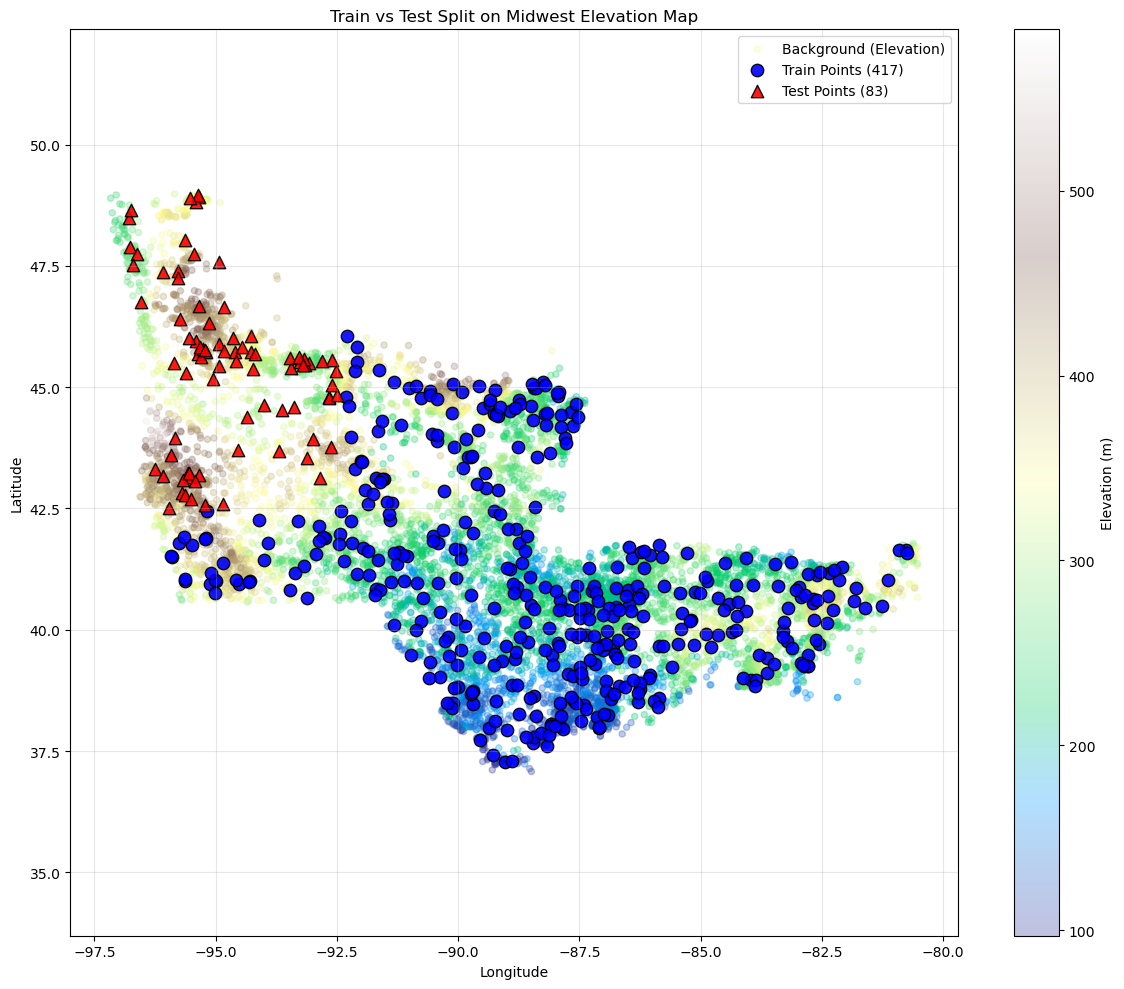

In [15]:

# Plot the new train/test split
plot_train_test_points(df, train_points_new, test_points_new)


In [17]:

# Create pool and test sets for exp6 with spatial generalization
# Pool: all train_points_new (train+val for model selection)
# Test: all test_points_new (spatially separated for true generalization test)

# Use all train points for pool
pool_exp6 = train_points_new

# Use all test points for testing (NW region)
test_exp6 = test_points_new

print(f"Pool size (train+val): {len(pool_exp6)}")
print(f"Test size: {len(test_exp6)}")
print(f"\nPool sample: {pool_exp6[:10]}")
print(f"Test sample: {test_exp6[:10]}")

# Create DataFrames and save to CSV
point_sets_dir = "/projects/standard/kumarv/shared/dwij/daycent/lib/configs/selection/point_sets"

# Pool dataset
pool_df = pd.DataFrame({'id': pool_exp6})
pool_df.to_csv(os.path.join(point_sets_dir, f"pool_exp6_{len(pool_exp6)}.csv"), index=False)
print(f"\nSaved pool_exp6_{len(pool_exp6)}.csv with {len(pool_df)} points")

# Test dataset
test_df = pd.DataFrame({'id': test_exp6})
test_df.to_csv(os.path.join(point_sets_dir, f"test_exp6_{len(test_exp6)}.csv"), index=False)
print(f"Saved test_exp6_{len(test_exp6)}.csv with {len(test_df)} points")


Pool size (train+val): 417
Test size: 83

Pool sample: ['168787', '173488', '192663', '241714', '261823', '261900', '270212', '272331', '276578', '279370']
Test sample: ['5679', '6583', '10703', '12583', '16827', '19240', '29226', '32556', '35330', '36558']

Saved pool_exp6_417.csv with 417 points
Saved test_exp6_83.csv with 83 points
